In [1]:
%matplotlib inline
from read_mist_models import EEP
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['font.family'] = 'monospace'

#Loading MIST data
eep = EEP("00100M.track.eep")
phase = eep.eeps['phase']

# Constants
AU = 1.496e11  # meters


age = eep.eeps['star_age']     # years
M = eep.eeps['star_mass']      # solar masses
logL = eep.eeps['log_L']


x = age/(10**9)
Lstar = 3.83e26
L = 10**logL * Lstar
Lstar = 3.83e26


print(phase)
print("Age goes up to",age[-1]/1e9, "Gyr")

Reading in: 00100M.track.eep
[-1. -1. -1. ...  6.  6.  6.]
Age goes up to 11.465471475297027 Gyr


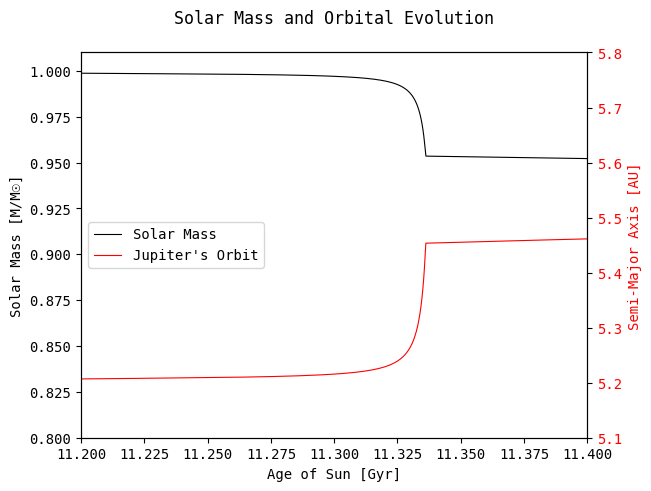

In [2]:
#Orbital Evolution
#Adiabatic Expansion: a(t) = a0 * M0/M(t)

#Jupiter
a0J = 5.2
a_tJ = a0J * M[0]/M

#Saturn
a0S = 9.5
a_tS = a0S * M[0]/M

x = age/(10**9)

def forward(M):
    a_tJ = 5.2 * M[0]/M
    return a_tJ

def backwards(a_tJ):
    return 5.2 * M[0] / a_tJ

x1_vals = x

fig, ax = plt.subplots(layout='constrained')
ax.plot(x1_vals, M, color = 'black', linewidth = 0.8, label = "Solar Mass")
ax.set_xlim(11.2,11.4)
ax.set_xlabel("Age of Sun [Gyr]")
ax.set_ylabel("Solar Mass [M/M☉]")
ax2 = ax.twinx() 
ax2.set_ylabel("Semi-Major Axis [AU]", color = "red")
ax2.plot(x1_vals, a_tJ, color = "red", linewidth = 0.8, label = "Jupiter's Orbit")
ax2.tick_params(axis='y', labelcolor = "red")

ax.plot(x1_vals, 100*a_tJ, color = "red", linewidth = 0.8, label = "Jupiter's Orbit")
ax.set_ylim(0.8,1.01)
ax2.set_ylim(5.1,5.8)
ax.legend(loc="center left")

plt.title("Solar Mass and Orbital Evolution\n")
plt.savefig(fname = "Solar Mass and Orbital", dpi = 600, bbox_inches = "tight")
#ax2.legend(loc="center")
#ax2 = ax.secondary_yaxis('right', functions=(forward, backwards))
#ax2.set_ylabel()
#ax2.tick_params(axis='y', labelcolor='tab:red')

793.9663608840156 K peak for 0.1 albedo
304.201552771329 avg CHeB T


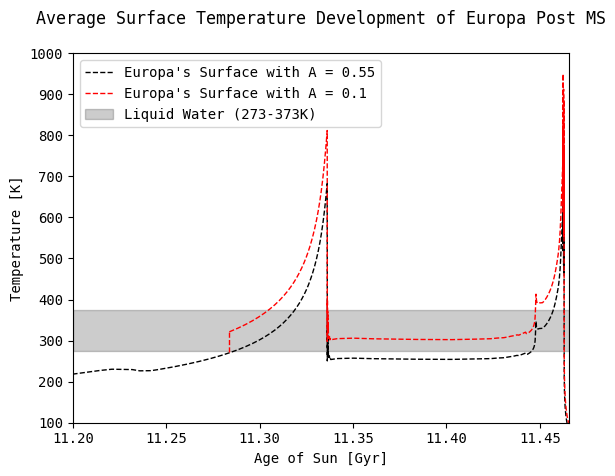

In [6]:
#Considering Tidal Heating and radiogenic heating
from scipy.constants import G

#For Phase Jumps
phase_jumps = []

for i in range(len(phase)-1):
    if phase[i] != phase[i+1]:
        phase_jumps.append(i)
        

#Tidal Flux and radiogenic heating
def total(Mpl, Rpl, Rmoon, orbital, A, e, k2, Q, a, sigma, radio):
    
    #calculate Edot
    n = np.sqrt(G*Mpl/orbital**3)
    Edot = (21/2) * (k2/Q) * (G*Mpl**2 * Rmoon**5 * n * e**2) / (orbital**6)

    #Heat Fluxes
    flux_star = L*(1-A)/(4*np.pi*(a*AU)**2)
    flux_tidal = Edot / (4*np.pi*Rmoon**2)
    flux_total = flux_star + flux_tidal + radio #total flux

    #Temperatures
    Teq = (flux_star/(4*sigma))**(0.25)
    Teff = (flux_total/(4*sigma))**(0.25) 
    T_star_tidal = ((flux_star + flux_tidal)/(4*sigma))**(0.25)
    
    T_tidal = (T_star_tidal- Teq)
    average_tidal = sum(T_tidal)/len(T_tidal) 
    
    return Teff, flux_tidal/flux_star[630], Teq


#Constants
Mjupiter = 1.898e27
Rjupiter = 71492e3
Reuropa = 1561e3
Orbit_europa = 671e6
ecc_europa = 0.0094
Aeu = 0.55 
sigma = 5.67e-8


sigma = 5.67*10**(-8)
radio = 7e-3 #taken from literature, usually between 6 and 9

k2 = 0.25 
Q = 150 


Teff_EUROPA, tidal, Teq = total(Mjupiter, Rjupiter, Reuropa, Orbit_europa, Aeu, ecc_europa, k2, Q, a_tJ, sigma, radio)
T_melt, tidal2, Teq2 = total(Mjupiter, Rjupiter, Reuropa, Orbit_europa, 0.1, ecc_europa, k2, Q, a_tJ, sigma, radio)

print(T_melt[phase_jumps[2]-1], "K peak for 0.1 albedo")
print(T_melt[phase_jumps[2]+30], "avg CHeB T") #+30 for good measure 


x = age/(10**9)

plt.plot(x, Teff_EUROPA, label = "Europa's Surface with A = 0.55", color = "black", linestyle="--",  linewidth = 1)
plt.plot(x[531:-1], T_melt[531:-1], label = "Europa's Surface with A = 0.1", color = "red", linestyle="--", linewidth = 1)
plt.axhspan(274, 374, color='black', alpha=0.2, label="Liquid Water (273-373K)")
plt.axvline(x[531], (273-100)/900, (T_melt[531]-100)/900, color = "red", linestyle="--", linewidth = 1)
plt.xlabel("Age of Sun [Gyr]")
plt.ylabel("Temperature [K]")
plt.xlim(11.2, x[-1])
plt.ylim(100, 1000)
#plt.ylim(50, 450)
plt.legend(loc='upper left')
plt.title("Average Surface Temperature Development of Europa Post MS\n")

#x[phase_jumps[2]+30:phase_jumps[3]] -----ignore
#T_melt[phase_jumps[2]+30:phase_jumps[3]] -----ignore

#plt.savefig(fname = "Surface_T,yes Albedo change, limited", dpi = 600, bbox_inches = "tight")
plt.show()

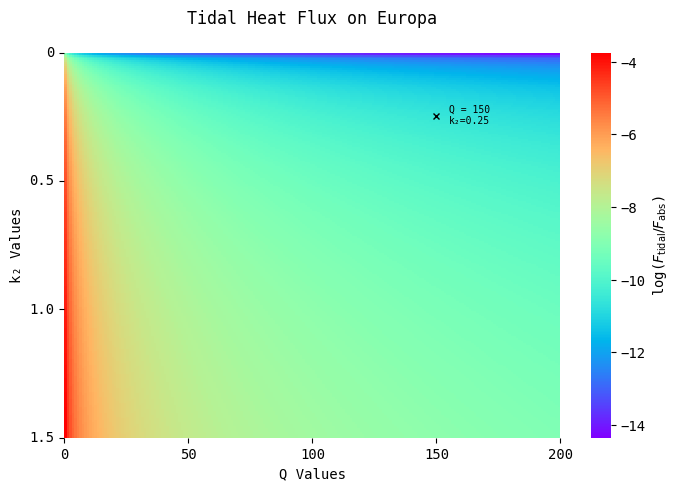

In [8]:
#Evaluation Tidal Heating effects with varying k2, Q
import seaborn as sns
import pandas as pd


k2_vals = [(i+1)*(3/400) for i in range(200)] #from 0 - 1.5, in 0.0075 increments
Q_vals = [i+1 for i in range(200)] #from 0 to 200, in 1 increment


#Temperature evaluation

matrix = np.zeros((0, 200))

for i in k2_vals:
    Tidal_Europa_list = []
    
    for j in Q_vals:
        Teff, tidal, Teff = total(Mjupiter, Rjupiter, Reuropa, Orbit_europa, Aeu, ecc_europa, i, j, a_tJ, sigma, radio)
        Tidal_Europa_list.append(tidal) 

    matrix = np.vstack((matrix, np.log(Tidal_Europa_list))) 

#Plotting

plt.figure(figsize=(8, 5))  # Adjust figure size ##done
ax = sns.heatmap(matrix, cmap = 'rainbow',
                cbar_kws={'label': r'log($F_{\rm tidal} / F_{\rm abs}$)'}) 

#Desired k2 tick labels
k2_tick_labels = [0, 0.5, 1.0, 1.5]

#Convert those physical values to matrix indices
step = 0.0075
k2_tick_positions = [val/step for val in k2_tick_labels]

ax.set_yticks(k2_tick_positions)
ax.set_yticklabels(k2_tick_labels, rotation=0)


#Desired Q tick labels
Q_tick_labels = [0, 50, 100, 150, 200]
Q_tick_position = [i for i in Q_tick_labels]

ax.set_xticks(Q_tick_position)
ax.set_xticklabels(Q_tick_labels, rotation=0)


plt.title("Tidal Heat Flux on Europa\n", fontsize=12)
plt.xlabel("Q Values")
plt.ylabel("k₂ Values")
plt.plot(150, 33, marker = "x", markersize = 5, color = "black") # europa


plt.text(155, 37, "Q = 150 \nk₂=0.25", color = "black", size = 7)


#plt.savefig(fname = "Tidal_Heatmap", dpi = 600, bbox_inches = "tight")
plt.show()

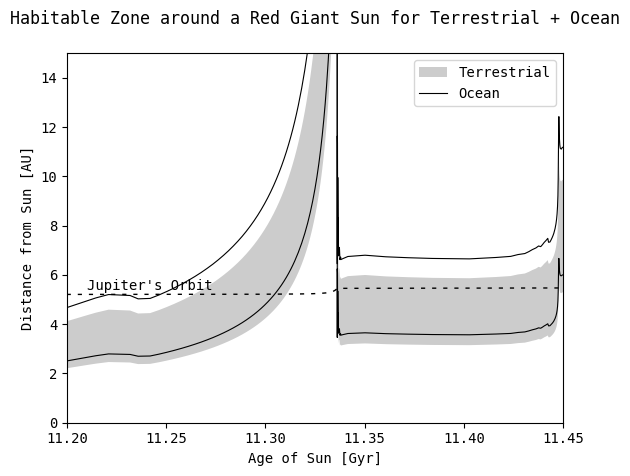

In [15]:
### Habitable Zone Plottings

def HZ(albedo):
    c = 16*np.pi*sigma
    lower = (((1-albedo)*L/(c*274**4))**0.5)/AU
    upper = (((1-albedo)*L/(c*374**4))**0.5)/AU

    return lower, upper

#HZ for terrestrial, icy and ocean
lower, upper = HZ(0.3) #lower is actually outer boundary
lower_icy, upper_icy = HZ(0.55)
lower_ocean, upper_ocean = HZ(0.1)


def boundaries(lower, upper):
    inner = upper[phase_jumps[2]+30]
    outer = lower[phase_jumps[2]+30]

    return inner, outer

#Boundaries for terrestrial, icy and ocean

CHeB_terrestrial_inner, CHeB_terrestrial_outer = boundaries(lower, upper)
CHeB_icy_inner, CHeB_icy_outer = boundaries(lower_icy, upper_icy)
CHeB_ocean_inner, CHeB_ocean_outer = boundaries(lower_ocean, upper_ocean)


#plotting Jupiter
plt.plot(x, a_tJ, color = 'black', linestyle = (0, (3, 5)), linewidth = 1)


#plotting boundaries
plt.fill_between(x, upper, lower, color='black', alpha=0.2, linewidth = 0, label = "Terrestrial")

plt.plot(x, lower_ocean, color = "black", linewidth = 0.8, label = "Ocean")
plt.plot(x, upper_ocean, color = "black", linewidth = 0.8)
#plt.fill_between(x, upper_icy

plt.xlim(11.2, 11.45)
plt.ylim(0,15)

plt.title("Habitable Zone around a Red Giant Sun for Terrestrial + Ocean\n")
plt.xlabel("Age of Sun [Gyr]")
plt.ylabel("Distance from Sun [AU]")
plt.text(11.21, 5.4, "Jupiter's Orbit", color = "black")
plt.legend()
plt.show()

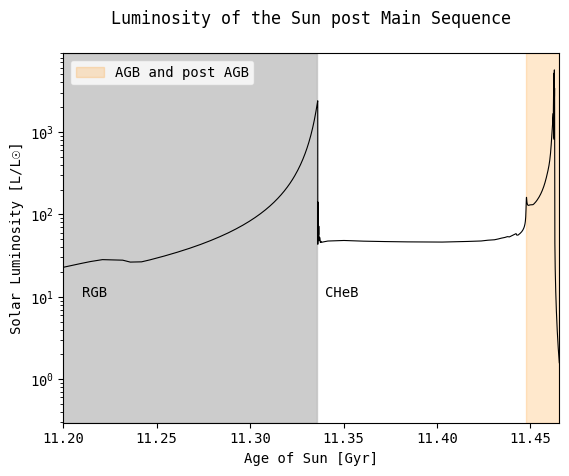

In [14]:
#For colour in the background
phase_jumps = []

for i in range(len(phase)-1):
    if phase[i] != phase[i+1]:
        phase_jumps.append(i)
  
#Plotting Luminosity

plt.plot(x, L/Lstar, color = 'black', linewidth = 0.8)
plt.xlabel("Age of Sun [Gyr]")
plt.ylabel("Solar Luminosity [L/L☉]")
plt.xlim(11.2, x[-1]) #x[phase_jumps[3]]
plt.yscale("log")


plt.axvspan(0, x[phase_jumps[1]], color = "yellow", alpha = 0.2) #ZAMS/MS
plt.axvspan(x[phase_jumps[1]],x[phase_jumps[2]], color = "black", alpha = 0.2) #RGB
plt.axvspan(x[phase_jumps[2]],x[phase_jumps[3]], color = "white", alpha = 0.2) #CHeB
plt.axvspan(x[phase_jumps[3]], x[-1], color = "darkorange", alpha = 0.2, label = "AGB and post AGB") 


plt.text(11.21, 10, "RGB")
plt.text(11.34, 10, "CHeB")
plt.legend()
    
plt.title("Luminosity of the Sun post Main Sequence\n")

#plt.savefig(fname = "Post MS", dpi = 600, bbox_inches = "tight")

plt.show()

In [17]:
# For temperature analysis during the temperature peak

#print(Teff_EUROPA[531]) # Roughly when it enters HZ conditions
#print(phase_jumps[2]-1) # 602


avg_new_albedo = [i for i in T_melt[531:602]]
avg_temp = sum(avg_new_albedo) / len(avg_new_albedo)


#print(average_temp, "K is the actual average temperature leading up to the CHeB")
print(avg_temp, "K is the average temperature leading up to the CHeB")
print((x[phase_jumps[2]-1]-x[531]) * 100, "Myrs from Europa's surface <273K to CHeB start")

524.7706475506654 K is the average temperature leading up to the CHeB
5.207341175934133 Myrs from Europa's surface <273K to CHeB start


In [19]:
# For velocity and Jeans escape analysis, Maxwell-Boltzmann distribution of kinetic gases
r = 1561e3 # assumed exobase is close to surface
M_eu = 4.8e22
from scipy.constants import Boltzmann
kb = Boltzmann
u = 1.6605e-27 #1u in kg

# Thermal energy
thermal = kb * T_melt[phase_jumps[2]+30] # Temperature is 308K, we use this value if we assume that there there is no atmospheric escape
thermal_ = kb * 524 

# Escape velocities 
Vesc = np.sqrt(2*G*M_eu/r)

# average gas velocities (but also need to consider collision rate?)
v_h2o = np.sqrt(2*thermal/(18*u)) 
v_o2 = np.sqrt(2*thermal/(16*u))
v_h2 = np.sqrt(2*thermal/(2*u))
v_h = np.sqrt(2*thermal/(1*u))

# for 524K
v_h_ = np.sqrt(2*thermal_/(1*u))


# Jeans Parameters
jeansh2o = G*M_eu*18*u/(r*thermal)
jeanso2 = G*M_eu*16*u/(r*thermal)
jeansh2 = G*M_eu*2*u/(r*thermal)
jeansh = G*M_eu*1*u/(r*thermal)


print(jeansh2o, "H2O")
print(jeanso2, "O2")
print(jeansh2, "H2")
print(jeansh, "H")


print("(",Vesc/1000, "km/s escape velocity for Europa )")

14.604988243715525 H2O
12.982211772191578 O2
1.6227764715239472 H2
0.8113882357619736 H
( 2.0259887376662644 km/s escape velocity for Europa )


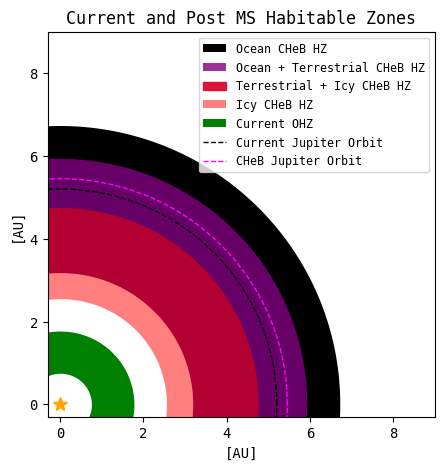

In [20]:
import matplotlib.patches as mpatches

recent_venus = 0.75
early_mars = 1.77
theta = np.linspace(0, 2*np.pi, 1000)

def xy_coords(radius, theta):
    x = radius * np.cos(theta)
    y = radius * np.sin(theta)

    return x,y


#jupiter
xJ, yJ = xy_coords(a0J, theta)
xJ2, yJ2 = xy_coords(5.45, theta)

#current hz
x01, y01 = xy_coords(recent_venus, theta) # Inner HZ
x02, y02 = xy_coords(early_mars, theta) # Outer HZ

#CHeB HZ, terrestrial
x_cheb_t_01, y_cheb_t_01 = xy_coords(CHeB_terrestrial_inner, theta)
x_cheb_t_02, y_cheb_t_02 = xy_coords(CHeB_terrestrial_outer, theta)

#CHeB HZ, icy
x_cheb_i_01, y_cheb_i_01 =  xy_coords(CHeB_icy_inner, theta)
x_cheb_i_02, y_cheb_i_02 = xy_coords(CHeB_icy_outer, theta)

#CHeB HZ, ocean world
x_cheb_o_01, y_cheb_o_01 = xy_coords(CHeB_ocean_inner, theta)
x_cheb_o_02, y_cheb_o_02 = xy_coords(CHeB_ocean_outer, theta)


plt.figure(figsize=(5,5))
plt.fill_between(x_cheb_o_02, y_cheb_o_02, color="black", alpha = 1, linewidth = 0, label = "Ocean CHeB HZ") #black
plt.fill_between(x_cheb_t_02, y_cheb_t_02, color='purple', alpha = 0.8, linewidth = 0, label = "Ocean + Terrestrial CHeB HZ") #0.8, purple
plt.fill_between(x_cheb_t_01, y_cheb_t_01, color='white', alpha = 1, linewidth = 0)
plt.axhspan(100, 101, label='Terrestrial + Icy CHeB HZ', color = "crimson")
plt.fill_between(x_cheb_i_02, y_cheb_i_02, color='red', alpha = 0.5, linewidth = 0, label = "Icy CHeB HZ") #0.5, red
plt.fill_between(x_cheb_i_01, y_cheb_i_01, color='white', alpha = 1, linewidth = 0)
plt.fill_between(x02, y02, color='green', alpha = 1, linewidth = 0, label = "Current OHZ")
plt.fill_between(x01, y01, color='white', linewidth = 0)
plt.plot(xJ,yJ, linewidth = 1, linestyle = "--", color = "black", label = "Current Jupiter Orbit")
plt.plot(xJ2,yJ2, linewidth = 1, linestyle = "--", color = "magenta", label = "CHeB Jupiter Orbit")
#plt.plot(x_cheb_t_01, y_cheb_t_01, linewidth = 1, linestyle = ":", color = "black", label = "Terrestrial Inner HZ")
plt.plot(0,0 , marker = "*", color='orange', markersize=10)
plt.xlim(-0.3,9)
plt.ylim(-0.3,9)
#plt.yticks(ylabel_positions, ylabel)
plt.ylabel("[AU]")
plt.xlabel("[AU]")
plt.title("Current and Post MS Habitable Zones")
plt.legend(fontsize = 'small', loc='upper right')
#plt.savefig(fname = "HZ radial, quarter, with ocean", dpi = 600, bbox_inches = "tight")